# Estimating the value of β and γ

$$\beta = \text{effective transmission rate per day}$$
$$\gamma = \text{recovery/removal rate per day}$$


Estimating β and γ from real COVID-19 data requires more than manually choosing values; this is essentially an inverse problem: you observe epidemic data and infer the SIR parameters that best reproduce those observations.

For the standard SIR model for COVID-19,

$$ \frac{dS}{dt}=-\beta\frac{SI}{N} $$ $$ \frac{dI}{dt}=\beta\frac{SI}{N}-\gamma I $$ $$ \frac{dR}{dt}=\gamma I $$

where β is the transmission rate, and γ is the recovery/removal rate Pant et al. (2026) [^1]. For estimating constant β and γ, ideally the dataset should contain: Date, Confirmed, Active infected, Recovered and Total population. This is extremely important because β, γ, and the initial conditions can interact during optimization.

In fact, identifiability studies show that estimating epidemic parameters becomes difficult when important states or parameters are not adequately observed.
Tuncer, N., & Le, T. T. (2018) [^2].

In this section, we will estimate β and γ by implementing the RK4 method with the help of the COVID-19 Dataset for Bangladesh from Kaggle. 


ESTIMATED SIR PARAMETERS
Country        : Bangladesh
Population N   : 164,689,383
Start date     : 2020-03-08
End date       : 2020-07-27
beta           : 0.1715094807
gamma          : 0.0942542420
R0 = beta/gamma: 1.8196473406


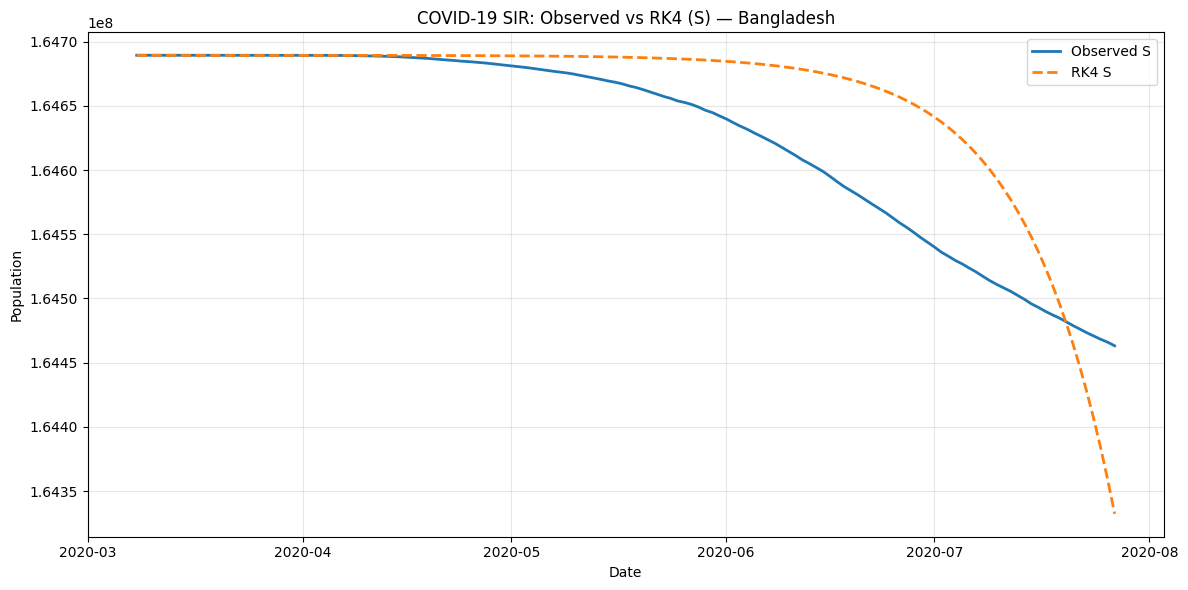

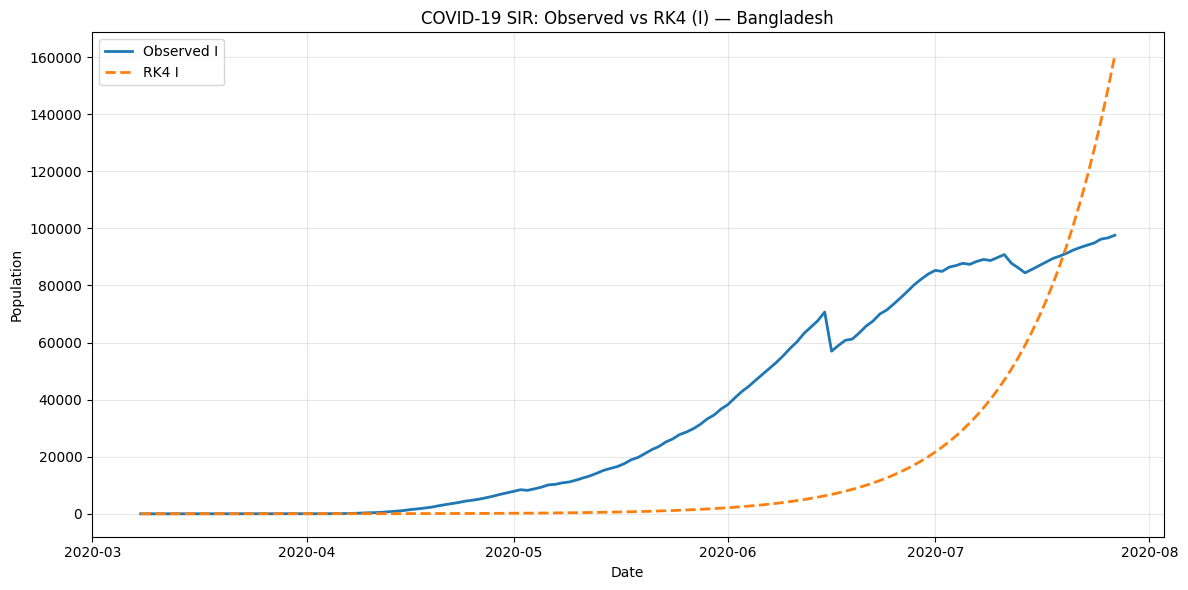

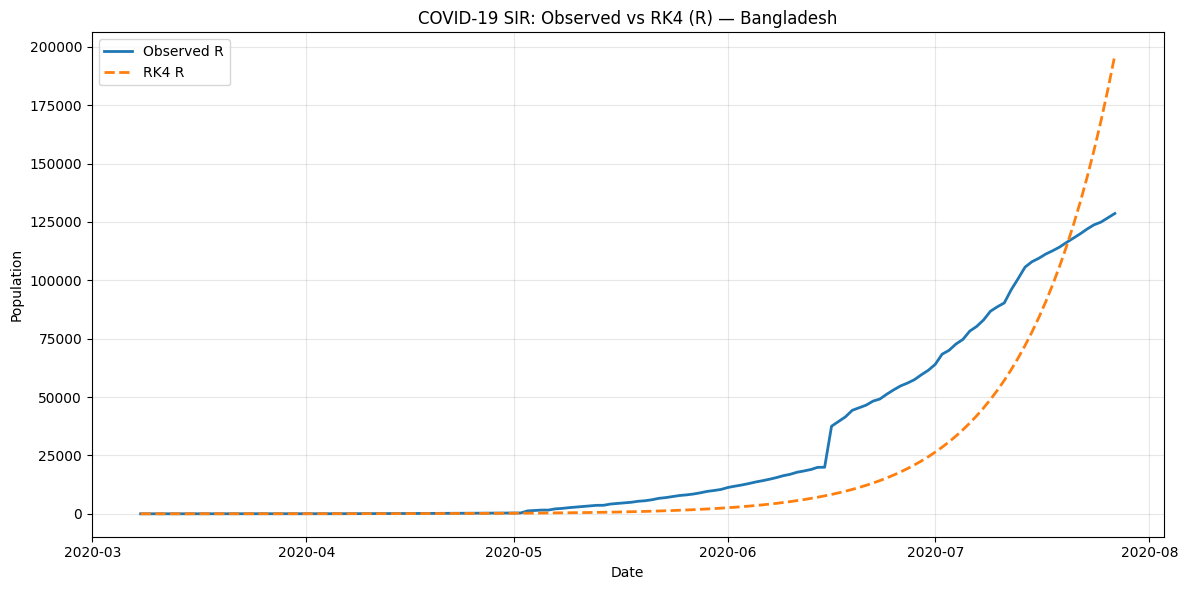


MODEL PERFORMANCE
Compartment           MAE                  MSE          RMSE       R2
          S 34,521.622536 2,550,213,550.984175 50,499.639117 0.522849
          I 22,818.473300 1,050,476,888.634334 32,411.061208 0.168832
          R 11,727.681623   375,884,687.230241 19,387.745801 0.756780

First 10 RK4 results:
      Date        S_RK4    I_RK4    R_RK4
2020-03-08 1.646894e+08 3.000000 0.000000
2020-03-09 1.646894e+08 3.240953 0.293972
2020-03-10 1.646894e+08 3.501259 0.611555
2020-03-11 1.646894e+08 3.782473 0.954646
2020-03-12 1.646894e+08 4.086272 1.325292
2020-03-13 1.646894e+08 4.414473 1.725709
2020-03-14 1.646894e+08 4.769033 2.158286
2020-03-15 1.646894e+08 5.152071 2.625606
2020-03-16 1.646894e+08 5.565874 3.130461
2020-03-17 1.646894e+08 6.012912 3.675864

FILES CREATED
CSV     : /kaggle/working/bangladesh_sir_rk4_results.csv
Excel   : /kaggle/working/bangladesh_sir_rk4_results.xlsx
Metrics : /kaggle/working/bangladesh_sir_metrics.csv
S plot  : /kaggle/working/banglad

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# COVID-19 SIR MODEL
# Parameter estimation + classical RK4 solution + metrics
# ============================================================

# ------------------------- CONFIG ----------------------------
INPUT_FILE = "/kaggle/input/datasets/abushayid/covid19/covid_19_clean_complete.csv"
COUNTRY = "Bangladesh"

# IMPORTANT:
# Use the actual total population of the selected country.
# This value is the 2020 population used for the Bangladesh example.
N = 164_689_383

OUTPUT_DIR = Path("/kaggle/working/")

CSV_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.csv"
EXCEL_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_rk4_results.xlsx"
METRICS_FILE = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_metrics.csv"

PLOT_S = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_S_observed_vs_rk4.png"
PLOT_I = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_I_observed_vs_rk4.png"
PLOT_R = OUTPUT_DIR / f"{COUNTRY.lower()}_sir_R_observed_vs_rk4.png"


# ============================================================
# 1. READ COVID-19 DATA
# ============================================================
df = pd.read_csv(INPUT_FILE)

required_columns = [
    "Country/Region", "Date", "Confirmed",
    "Deaths", "Recovered", "Active"
]

missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"])

data = df[df["Country/Region"].eq(COUNTRY)].copy()

if data.empty:
    raise ValueError(
        f"No data found for '{COUNTRY}'. "
        f"Check the COUNTRY variable."
    )

# If the country has province/state rows, aggregate them by date.
data = (
    data.groupby("Date", as_index=False)
    [["Confirmed", "Deaths", "Recovered", "Active"]]
    .sum()
    .sort_values("Date")
    .reset_index(drop=True)
)

# ============================================================
# Construct observed S, I, R
# ============================================================
# Active = I
# Recovered + Deaths = R (removed)
# S = N - I - R
#
# Note: deaths are included in R because classical SIR has
# a single removed compartment.
data["I_obs"] = data["Active"].astype(float)
data["R_obs"] = (
    data["Recovered"].astype(float)
    + data["Deaths"].astype(float)
)
data["S_obs"] = N - data["I_obs"] - data["R_obs"]

if (data["S_obs"] < 0).any():
    raise ValueError(
        "Some S_obs values are negative. "
        "Increase/correct N for the selected country."
    )

# The dataset begins with zero active infections.
# Start estimation at the first day with I > 0.
positive_indices = np.flatnonzero(
    data["I_obs"].to_numpy() > 0
)

if len(positive_indices) == 0:
    raise ValueError("No positive Active-infection observations found.")

start_idx = int(positive_indices[0])

fit_data = data.iloc[start_idx:].copy().reset_index(drop=True)

S_obs = fit_data["S_obs"].to_numpy(dtype=float)
I_obs = fit_data["I_obs"].to_numpy(dtype=float)
R_obs = fit_data["R_obs"].to_numpy(dtype=float)

t = np.arange(len(fit_data), dtype=float)

# Initial SIR state
y0 = np.array(
    [S_obs[0], I_obs[0], R_obs[0]],
    dtype=float
)

# ============================================================
# 2. ESTIMATE beta AND gamma
# ============================================================

def sir_rhs(y, beta, gamma, population):
    """
    Normalized SIR equations:
        dS/dt = -beta*S*I/N
        dI/dt =  beta*S*I/N - gamma*I
        dR/dt =  gamma*I
    """
    S, I, R = y

    dS = -beta * S * I / population
    dI = beta * S * I / population - gamma * I
    dR = gamma * I

    return np.array([dS, dI, dR], dtype=float)


def simulate_for_estimation(beta, gamma):
    """
    Numerically integrate SIR during parameter fitting.
    solve_ivp is used only for parameter estimation.
    The final reported solution is produced independently
    with classical RK4 below.
    """
    solution = solve_ivp(
        lambda time, state: sir_rhs(
            state, beta, gamma, N
        ),
        [t[0], t[-1]],
        y0,
        t_eval=t,
        method="RK45",
        rtol=1e-7,
        atol=1e-2
    )

    if not solution.success:
        raise RuntimeError(solution.message)

    return solution.y


observed = np.vstack([S_obs, I_obs, R_obs])

# Normalize residuals so the very large S compartment does not
# completely dominate I and R during optimization.
scales = np.array([
    max(N, 1.0),
    max(I_obs.max(), 1.0),
    max(R_obs.max(), 1.0)
])


def residual_log_parameters(log_parameters):
    """
    Optimize log(beta), log(gamma), which guarantees
    beta > 0 and gamma > 0.
    """
    beta, gamma = np.exp(log_parameters)

    predicted = simulate_for_estimation(beta, gamma)

    return (
        (predicted - observed)
        / scales[:, None]
    ).ravel()


# Initial guess; change if desired.
initial_guess = np.array([0.30, 0.10])

fit = least_squares(
    residual_log_parameters,
    np.log(initial_guess),
    bounds=(
        np.log([1e-6, 1e-6]),
        np.log([10.0, 10.0])
    ),
    max_nfev=2000
)

beta, gamma = np.exp(fit.x)

# Basic reproduction number for the normalized SIR model.
R0 = beta / gamma

print("\n" + "=" * 70)
print("ESTIMATED SIR PARAMETERS")
print("=" * 70)
print(f"Country        : {COUNTRY}")
print(f"Population N   : {N:,}")
print(f"Start date     : {fit_data['Date'].iloc[0].date()}")
print(f"End date       : {fit_data['Date'].iloc[-1].date()}")
print(f"beta           : {beta:.10f}")
print(f"gamma          : {gamma:.10f}")
print(f"R0 = beta/gamma: {R0:.10f}")
print("=" * 70)


# ============================================================
# 3. CLASSICAL RK4 SOLUTION
# ============================================================

def rk4_sir(y_initial, beta, gamma, population,
            n_steps, h=1.0):
    """
    Classical fourth-order Runge-Kutta solution
    for the normalized SIR model.
    """

    y = np.array(y_initial, dtype=float)

    result = np.zeros(
        (n_steps + 1, 3),
        dtype=float
    )

    result[0] = y

    def f(state):
        return sir_rhs(
            state,
            beta,
            gamma,
            population
        )

    for step in range(n_steps):

        k1 = f(y)
        k2 = f(y + 0.5 * h * k1)
        k3 = f(y + 0.5 * h * k2)
        k4 = f(y + h * k3)

        y = y + (
            h / 6.0
        ) * (
            k1 + 2*k2 + 2*k3 + k4
        )

        # Numerical safeguard.
        y = np.maximum(y, 0.0)

        result[step + 1] = y

    return result


rk4_solution = rk4_sir(
    y_initial=y0,
    beta=beta,
    gamma=gamma,
    population=N,
    n_steps=len(fit_data) - 1,
    h=1.0
)

fit_data["S_RK4"] = rk4_solution[:, 0]
fit_data["I_RK4"] = rk4_solution[:, 1]
fit_data["R_RK4"] = rk4_solution[:, 2]


# ============================================================
# 4. COMPLETE S, I, R VALUES FOR EVERY DAY
# ============================================================

results = fit_data[
    [
        "Date",
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active",
        "S_obs",
        "I_obs",
        "R_obs",
        "S_RK4",
        "I_RK4",
        "R_RK4"
    ]
].copy()


# ============================================================
# 5. SAVE CSV AND EXCEL
# ============================================================

results.to_csv(
    CSV_FILE,
    index=False
)

metrics_rows = []

for compartment, observed_column, rk4_column in [
    ("S", "S_obs", "S_RK4"),
    ("I", "I_obs", "I_RK4"),
    ("R", "R_obs", "R_RK4")
]:

    y_true = results[observed_column].to_numpy()
    y_pred = results[rk4_column].to_numpy()

    mae = mean_absolute_error(
        y_true, y_pred
    )

    mse = mean_squared_error(
        y_true, y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true, y_pred
    )

    metrics_rows.append({
        "Compartment": compartment,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

metrics = pd.DataFrame(metrics_rows)

parameter_table = pd.DataFrame({
    "Parameter": [
        "Country",
        "Population_N",
        "beta",
        "gamma",
        "R0",
        "Start_Date",
        "End_Date"
    ],
    "Value": [
        COUNTRY,
        N,
        beta,
        gamma,
        R0,
        str(results["Date"].iloc[0].date()),
        str(results["Date"].iloc[-1].date())
    ]
})

with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl"
) as writer:

    results.to_excel(
        writer,
        sheet_name="SIR_RK4_Results",
        index=False
    )

    metrics.to_excel(
        writer,
        sheet_name="Metrics",
        index=False
    )

    parameter_table.to_excel(
        writer,
        sheet_name="Parameters",
        index=False
    )

metrics.to_csv(
    METRICS_FILE,
    index=False
)


# ============================================================
# 6. OBSERVED VS RK4 PLOTS
# ============================================================
# Three separate figures are used because S is much larger
# than I and R and would otherwise hide their differences.

def make_comparison_plot(
    date,
    observed_values,
    rk4_values,
    compartment,
    filename
):

    plt.figure(figsize=(12, 6))

    plt.plot(
        date,
        observed_values,
        label=f"Observed {compartment}",
        linewidth=2
    )

    plt.plot(
        date,
        rk4_values,
        "--",
        label=f"RK4 {compartment}",
        linewidth=2
    )

    plt.xlabel("Date")
    plt.ylabel("Population")
    plt.title(
        f"COVID-19 SIR: Observed vs RK4 "
        f"({compartment}) — {COUNTRY}"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


make_comparison_plot(
    results["Date"],
    results["S_obs"],
    results["S_RK4"],
    "S",
    PLOT_S
)

make_comparison_plot(
    results["Date"],
    results["I_obs"],
    results["I_RK4"],
    "I",
    PLOT_I
)

make_comparison_plot(
    results["Date"],
    results["R_obs"],
    results["R_RK4"],
    "R",
    PLOT_R
)


# ============================================================
# 7. PRINT METRICS
# ============================================================

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(
    metrics.to_string(
        index=False,
        float_format=lambda x: f"{x:,.6f}"
    )
)

print("\nFirst 10 RK4 results:")
print(
    results[
        [
            "Date",
            "S_RK4",
            "I_RK4",
            "R_RK4"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("FILES CREATED")
print("=" * 70)
print(f"CSV     : {CSV_FILE}")
print(f"Excel   : {EXCEL_FILE}")
print(f"Metrics : {METRICS_FILE}")
print(f"S plot  : {PLOT_S}")
print(f"I plot  : {PLOT_I}")
print(f"R plot  : {PLOT_R}")
print("=" * 70)

2026-08-31 20:59:46.795987: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,492 (64.42 KB)

 Trainable params: 16,492 (64.42 KB)

...

None
Epoch 1/150
236/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0362 - mae: 0.0982

2026-08-31 20:59:49.967078: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0180 - mae: 0.0606 - val_loss: 0.0121 - val_mae: 0.0441
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0084 - mae: 0.0377 - val_loss: 0.0066 - val_mae: 0.0294
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - mae: 0.0227 - val_loss: 0.0039 - val_mae: 0.0188
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0146
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - mae: 0.0111 - val_loss: 0.0014 - val_mae: 0.0136
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5927e-04 - mae: 0.0090 - val_loss: 2.4520e-04 - val_mae: 0.0063
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1409e-04 - mae: 0.0058 - val_loss: 3.8072e-04 - val_mae: 0.0078
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0923e-04 - mae: 0.0066 - val_loss: 0.0022 - val_mae: 0.0162
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━

2026-08-31 21:02:07.688319: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


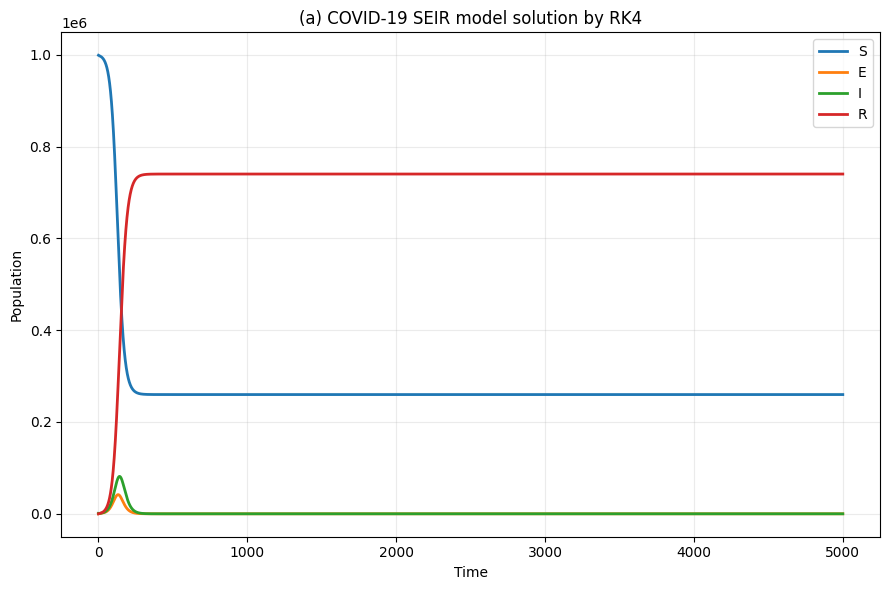

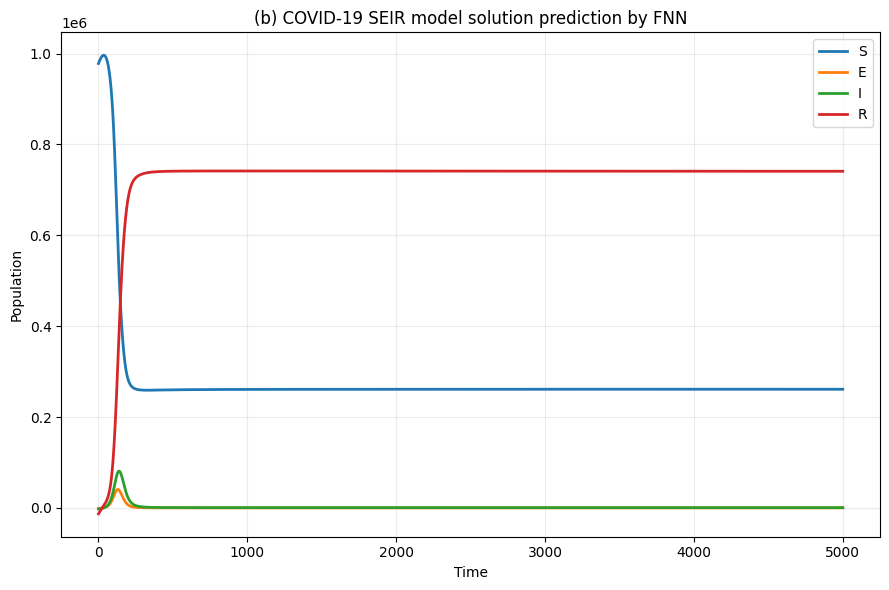

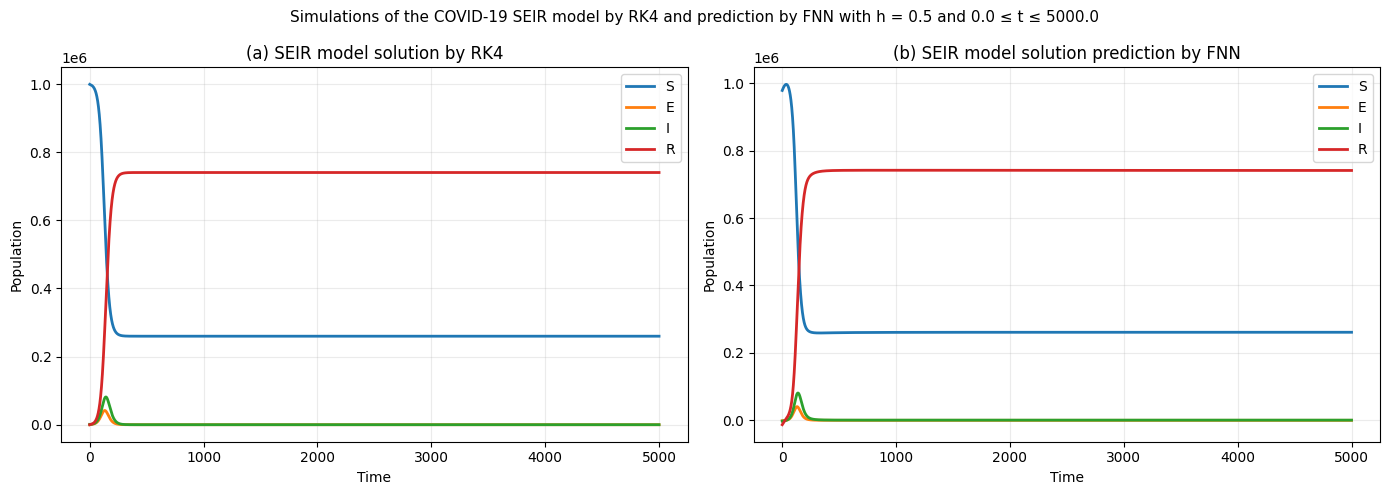

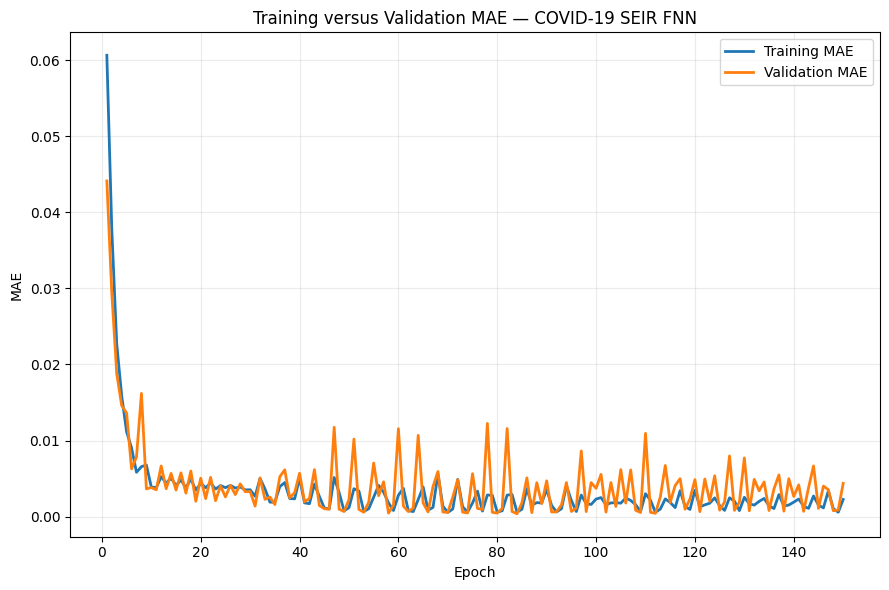

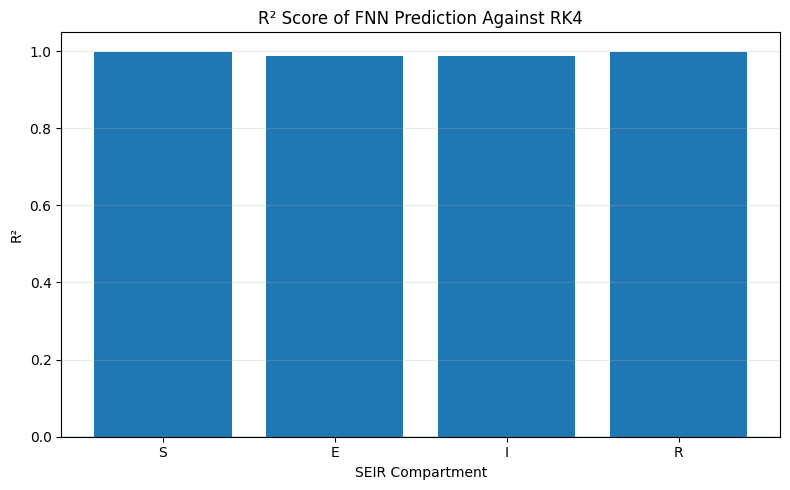

/tmp/ipykernel_16/3678915318.py:1075: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_16/3678915318.py:1081: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_16/3678915318.py:1087: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_16/3678915318.py:1093: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_16/3678915318.py:1099: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_16/3678915318.py:1105: FutureWarn


COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment         MAE          MSE        RMSE       R2
          S 1940.653667 1.681622e+07 4100.758428 0.998510
          E  134.361332 2.843884e+05  533.280822 0.986281
          I  692.519063 1.022104e+06 1010.991575 0.987683
          R 1964.095479 3.729509e+07 6106.970383 0.997090

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.002625        0.000031              99.737476
          E        0.003099        0.000156              99.690129
          I        0.008374        0.000147              99.162568
          R        0.002609        0.000067              99.739074

Population conservation check:
RK4 maximum absolute error = 0

In [2]:
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# COVID-19 SEIR RK4-FNN Synthetic Experiment
#
# Method:
#   1. Generate synthetic SEIR data using RK4
#   2. Min-Max normalization
#   3. 80/20 train-validation split
#   4. FNN input = t
#   5. FNN output = [S(t), E(t), I(t), R(t)]
#   6. MSE loss
#   7. Adam optimizer
#   8. tanh activation
#   9. 150 epochs
#
# SEIR compartments:
#   S = Susceptible
#   E = Exposed
#   I = Infectious
#   R = Recovered
# ============================================================


# ============================================================
# Output directory
# ============================================================

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# SEIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# FNN SETTINGS
# ============================================================

SEED = 42

EPOCHS = 150
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 128, 80, 40, 16]


# ============================================================
# RANDOM SEED
# ============================================================

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ============================================================
# SEIR DIFFERENTIAL EQUATIONS
# ============================================================
#
# dS/dt = -beta*S*I/N
#
# dE/dt = beta*S*I/N - sigma*E
#
# dI/dt = sigma*E - gamma*I
#
# dR/dt = gamma*I
#
# ============================================================

def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])


# ============================================================
# RK4 ONE STEP
# ============================================================

def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)


# ============================================================
# ARTICLE-STYLE FNN
# ============================================================
#
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())


# ============================================================
# TRAIN FNN
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(
    hist.history
)

Hdf.insert(
    0,
    'epoch',
    np.arange(
        1,
        len(Hdf) + 1
    )
)


Hdf.to_csv(
    OUT / 'FNN_training_history.csv',
    index=False
)


# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)


# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)


# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )


# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    OUT / 'COVID19_SEIR_FNN.keras'
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

# COVID-19 SIR RK4-FNN synthetic experiment

Model: "COVID19_SIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,475 (64.36 KB)

 Trainable params: 16,475 (64.36 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0443 - mae: 0.0964

2026-08-31 21:02:20.480378: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0177 - mae: 0.0545 - val_loss: 0.0099 - val_mae: 0.0386
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0079 - mae: 0.0352 - val_loss: 0.0072 - val_mae: 0.0303
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0050 - mae: 0.0245 - val_loss: 0.0049 - val_mae: 0.0203
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0028 - mae: 0.0151 - val_loss: 0.0034 - val_mae: 0.0132
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - mae: 0.0114 - val_loss: 0.0021 - val_mae: 0.0097
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017 - mae: 0.0095 - val_loss: 0.0011 - val_mae: 0.0065
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0012 - mae: 0.0080 - val_loss: 4.0442e-04 - val_mae: 0.0044
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0956e-04 - mae: 0.0062 - val_loss: 1.8191e-04 - val_mae: 0.0043
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

2026-08-31 21:04:39.597491: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


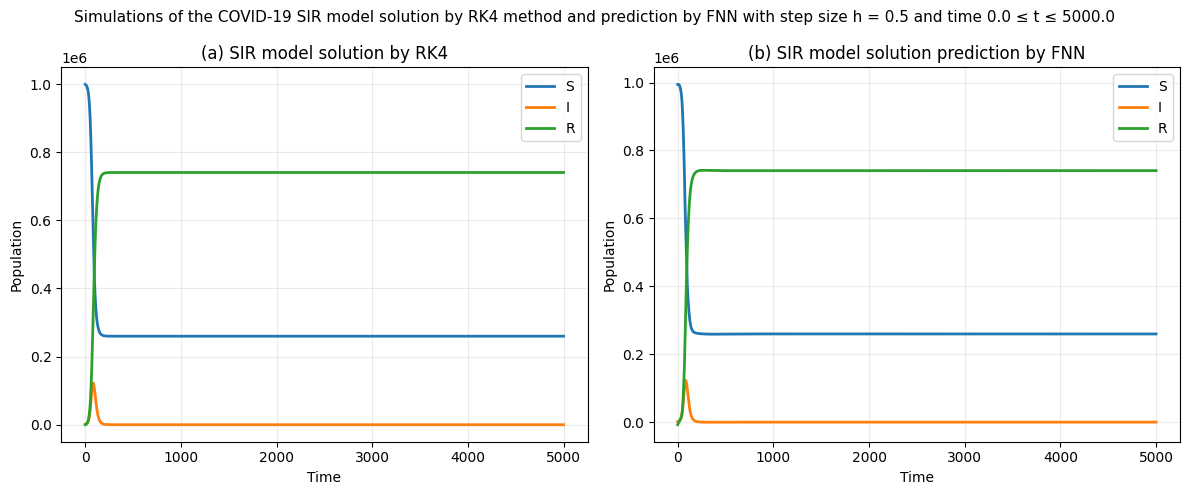

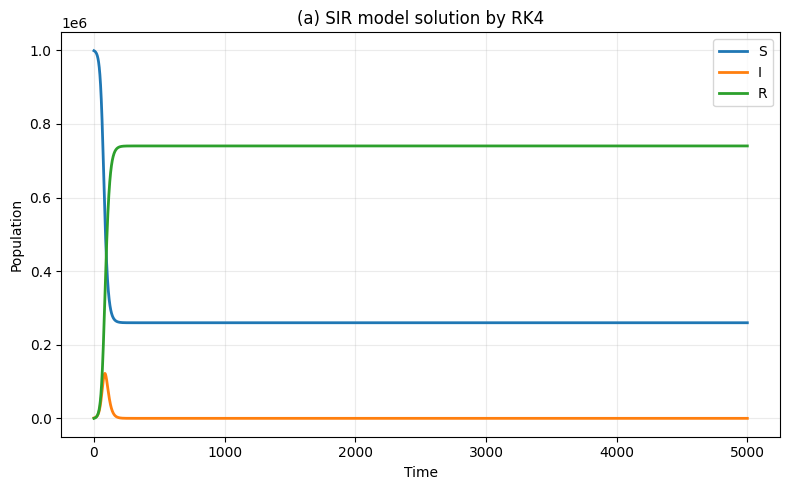

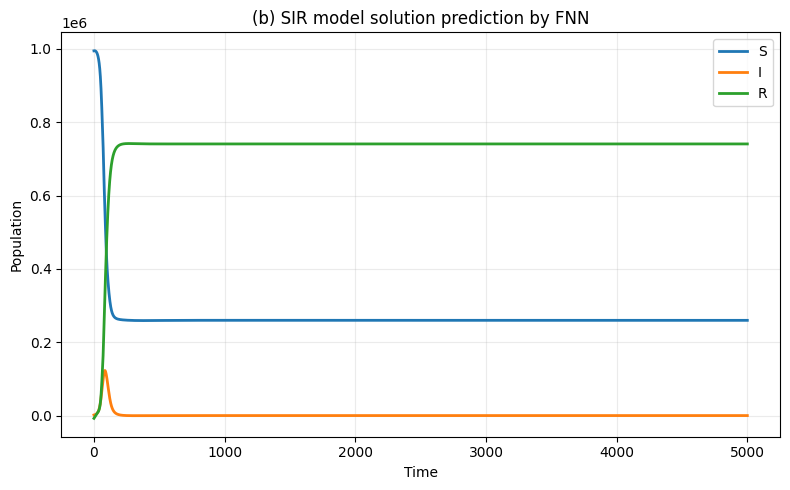

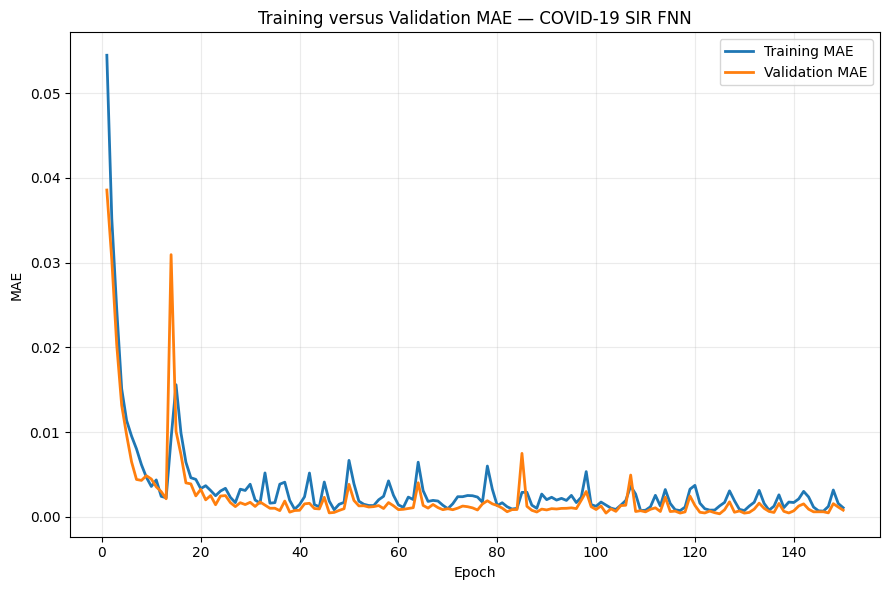

/tmp/ipykernel_16/3891556176.py:113: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(w,'RK4_Data',index=False); res.to_excel(w,'RK4_vs_FNN',index=False); metrics.to_excel(w,'Metrics',index=False); normdf.to_excel(w,'Normalized_Accuracy',index=False); Hdf.to_excel(w,'Training_History',index=False); params.to_excel(w,'Parameters',index=False)



DONE
beta=0.17150948, gamma=0.09425424, beta/gamma=1.819647
Initial state: S0=999,000, I0=1,000, R0=0, N=1,000,000
RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment        MAE          MSE        RMSE       R2
          S 237.904765 1.467337e+06 1211.336959 0.999787
          I 160.975846 6.749455e+04  259.797130 0.999459
          R 521.109094 1.583646e+06 1258.430016 0.999799

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.000322        0.000003              99.967817
          I        0.001282        0.000004              99.871751
          R        0.000689        0.000003              99.931056

Outputs: /kaggle/working/COVID19_SIR_RK4_FNN_synthetic_article_method


In [3]:
# ============================================================
# COVID-19 SIR RK4-FNN synthetic experiment
# Method follows the supplied article: RK4-generated data,
# min-max scaling, 80/20 train-validation split, FNN input=t,
# output=[S(t),I(t),R(t)], MSE loss, Adam, tanh, 150 epochs.
# ============================================================

OUT = Path('/kaggle/working/COVID19_SIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)

BETA = 0.17150948
GAMMA = 0.09425424
S0, I0, R0 = 999000.0, 1000.0, 0.0   # edit if desired
N = S0 + I0 + R0
T0, T1, H = 0.0, 5000.0, 0.5
SEED = 42
EPOCHS, BATCH_SIZE = 150, 32
HIDDEN = [16, 128, 80, 40, 16]  # published best SIR configuration

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
try: tf.config.experimental.enable_op_determinism()
except Exception: pass

# -------------------- SIR equations ---------------------------
def rhs(t, y):
    S, I, R = y
    return np.array([-BETA*S*I/N, BETA*S*I/N-GAMMA*I, GAMMA*I])

def rk4_step(t, y, h):
    k1 = h*rhs(t, y)
    k2 = h*rhs(t+h/2, y+k1/2)
    k3 = h*rhs(t+h/2, y+k2/2)
    k4 = h*rhs(t+h, y+k3)
    return np.maximum(y+(k1+2*k2+2*k3+k4)/6, 0.0)

# -------------------- RK4 synthetic data -----------------------
t = np.arange(T0, T1+H/2, H)
t[-1] = T1
y = np.zeros((len(t),3)); y[0] = [S0,I0,R0]
for j in range(len(t)-1): y[j+1] = rk4_step(t[j], y[j], H)

rk4 = pd.DataFrame({'t':t,'S_RK4':y[:,0],'I_RK4':y[:,1],'R_RK4':y[:,2]})
rk4['Total_RK4'] = rk4[['S_RK4','I_RK4','R_RK4']].sum(axis=1)
rk4.to_csv(OUT/'COVID19_SIR_RK4_synthetic_data.csv', index=False)

# -------------------- Article-style FNN ------------------------
# Article maps time t -> S,I,R (not state(t)->state(t+h)).
X, Y = t.reshape(-1,1), y.copy()
xsc, ysc = MinMaxScaler(), MinMaxScaler()
Xs, Ys = xsc.fit_transform(X), ysc.fit_transform(Y)
Xtr, Xva, Ytr, Yva = train_test_split(Xs, Ys, test_size=.20, random_state=SEED, shuffle=True)

model = keras.Sequential([layers.Input((1,))] +
    [layers.Dense(u, activation='tanh') for u in HIDDEN] +
    [layers.Dense(3, activation='linear')], name='COVID19_SIR_FNN')
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
print(model.summary())
hist = model.fit(Xtr, Ytr, validation_data=(Xva,Yva), epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=1)

Hdf = pd.DataFrame(hist.history); Hdf.insert(0,'epoch',np.arange(1,len(Hdf)+1)); Hdf.to_csv(OUT/'FNN_training_history.csv',index=False)

# Full-domain FNN prediction, as in article tables/figure
pred = ysc.inverse_transform(model.predict(Xs,batch_size=BATCH_SIZE,verbose=1))
Sfnn, Ifnn, Rfnn = pred.T

# Raw network predictions are retained; optional nonnegative version is used for plots/metrics.
Sfnn = np.maximum(Sfnn,0); Ifnn=np.maximum(Ifnn,0); Rfnn=np.maximum(Rfnn,0)

res = pd.DataFrame({'t':t,'S_RK4':y[:,0],'I_RK4':y[:,1],'R_RK4':y[:,2],
                    'S_FNN':Sfnn,'I_FNN':Ifnn,'R_FNN':Rfnn})
res['RK4_Total']=res[['S_RK4','I_RK4','R_RK4']].sum(axis=1)
res['FNN_Total']=res[['S_FNN','I_FNN','R_FNN']].sum(axis=1)
res['FNN_Total_Error']=res['FNN_Total']-N
res.to_csv(OUT/'COVID19_SIR_RK4_vs_FNN_complete.csv',index=False)

# -------------------- Metrics ----------------------------------
rows=[]
for k,name in enumerate(['S','I','R']):
    a,p=y[:,k],pred[:,k]
    rows.append({'Compartment':name,'MAE':mean_absolute_error(a,p),
                 'MSE':mean_squared_error(a,p),'RMSE':np.sqrt(mean_squared_error(a,p)),
                 'R2':r2_score(a,p)})
metrics=pd.DataFrame(rows); metrics.to_csv(OUT/'COVID19_SIR_RK4_FNN_metrics.csv',index=False)

# Article-style normalized MAE and accuracy-like score
norm=[]
Pscaled=ysc.transform(np.column_stack([Sfnn,Ifnn,Rfnn]))
for k,name in enumerate(['S','I','R']):
    mae=mean_absolute_error(Ys[:,k],Pscaled[:,k])
    norm.append({'Compartment':name,'Normalized_MAE':mae,'Normalized_MSE':mean_squared_error(Ys[:,k],Pscaled[:,k]),'Accuracy_like_percent':(1-mae)*100})
normdf=pd.DataFrame(norm); normdf.to_csv(OUT/'COVID19_SIR_FNN_normalized_accuracy.csv',index=False)

# -------------------- Figure 2 style ---------------------------
fig, ax = plt.subplots(1,2,figsize=(12,5))
for a, data, title in [(ax[0],y,'(a) SIR model solution by RK4'),(ax[1],pred,'(b) SIR model solution prediction by FNN')]:
    a.plot(t,data[:,0],label='S',linewidth=2); a.plot(t,data[:,1],label='I',linewidth=2); a.plot(t,data[:,2],label='R',linewidth=2)
    a.set_title(title); a.set_xlabel('Time'); a.set_ylabel('Population'); a.legend(); a.grid(alpha=.25)
fig.suptitle(f'Simulations of the COVID-19 SIR model solution by RK4 method and prediction by FNN with step size h = {H} and time {T0} ≤ t ≤ {T1}',fontsize=11)
fig.tight_layout(); fig.savefig(OUT/'Figure2_COVID19_SIR_RK4_vs_FNN.png',dpi=300,bbox_inches='tight'); plt.show()

# Individual panels
for data,title,file in [(y,'(a) SIR model solution by RK4','Figure2a_RK4_SIR.png'),(pred,'(b) SIR model solution prediction by FNN','Figure2b_FNN_SIR.png')]:
    plt.figure(figsize=(8,5)); plt.plot(t,data[:,0],label='S',lw=2); plt.plot(t,data[:,1],label='I',lw=2); plt.plot(t,data[:,2],label='R',lw=2); plt.title(title); plt.xlabel('Time'); plt.ylabel('Population'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(OUT/file,dpi=300,bbox_inches='tight'); plt.show()

# Figure 4 style training/validation MAE
plt.figure(figsize=(9,6)); plt.plot(Hdf.epoch,Hdf.mae,label='Training MAE',lw=2); plt.plot(Hdf.epoch,Hdf.val_mae,label='Validation MAE',lw=2); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.title('Training versus Validation MAE — COVID-19 SIR FNN'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.savefig(OUT/'Figure4_style_training_validation_MAE.png',dpi=300,bbox_inches='tight'); plt.show()

# -------------------- Excel ------------------------------------
params=pd.DataFrame({'Parameter':['Beta','Gamma','beta/gamma','S0','I0','R0','N','Time_start','Time_end','Step_h','Samples','FNN_input','FNN_output','Normalization','Train','Validation','Random_state','Activation','Optimizer','Hidden_layers','Epochs','Batch_size'],
                     'Value':[BETA,GAMMA,BETA/GAMMA,S0,I0,R0,N,T0,T1,H,len(t),'t','S(t), I(t), R(t)','Min-Max [0,1]','80%','20%',SEED,'tanh','Adam',str(HIDDEN),EPOCHS,BATCH_SIZE]})
with pd.ExcelWriter(OUT/'COVID19_SIR_RK4_FNN_complete_results.xlsx',engine='openpyxl') as w:
    rk4.to_excel(w,'RK4_Data',index=False); res.to_excel(w,'RK4_vs_FNN',index=False); metrics.to_excel(w,'Metrics',index=False); normdf.to_excel(w,'Normalized_Accuracy',index=False); Hdf.to_excel(w,'Training_History',index=False); params.to_excel(w,'Parameters',index=False)
model.save(OUT/'COVID19_SIR_FNN.keras')

print('\n'+'='*75); print('DONE'); print('='*75)
print(f'beta={BETA:.8f}, gamma={GAMMA:.8f}, beta/gamma={BETA/GAMMA:.6f}')
print(f'Initial state: S0={S0:,.0f}, I0={I0:,.0f}, R0={R0:,.0f}, N={N:,.0f}')
print(f'RK4: h={H}, t=[{T0},{T1}], samples={len(t):,}')
print('\nMetrics (FNN vs RK4):'); print(metrics.to_string(index=False))
print('\nNormalized accuracy-like score:'); print(normdf.to_string(index=False))
print('\nOutputs:', OUT)

Model: "COVID19_SEIR_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 80)             │        10,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,492 (64.42 KB)

 Trainable params: 16,492 (64.42 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/150
234/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0364 - mae: 0.0985

2026-08-31 21:04:50.630560: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0180 - mae: 0.0606 - val_loss: 0.0121 - val_mae: 0.0441
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0084 - mae: 0.0377 - val_loss: 0.0066 - val_mae: 0.0294
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0044 - mae: 0.0227 - val_loss: 0.0039 - val_mae: 0.0188
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025 - mae: 0.0159 - val_loss: 0.0019 - val_mae: 0.0146
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0013 - mae: 0.0111 - val_loss: 0.0014 - val_mae: 0.0136
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5927e-04 - mae: 0.0090 - val_loss: 2.4520e-04 - val_mae: 0.0063
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1409e-04 - mae: 0.0058 - val_loss: 3.8072e-04 - val_mae: 0.0078
Epoch 8/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.0923e-04 - mae: 0.0066 - val_loss: 0.0022 - val_mae: 0.0162
Epoch 9/150
250/250 ━━━━━━━━━━━━━━━━━━━━

2026-08-31 21:07:15.531788: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


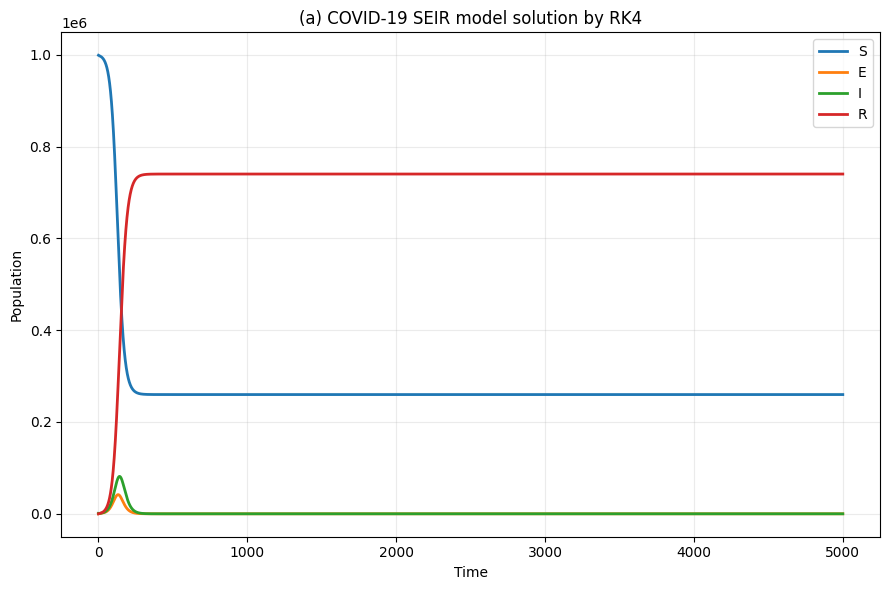

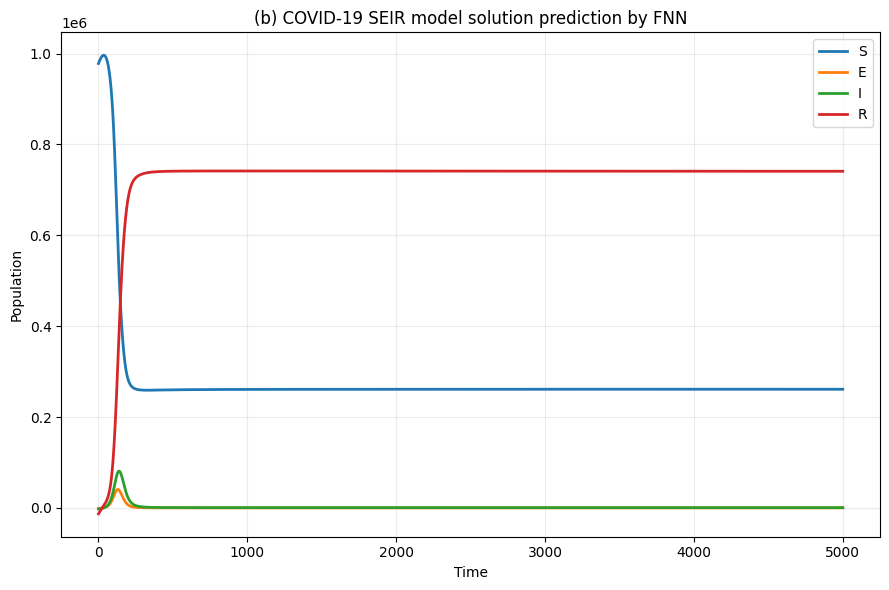

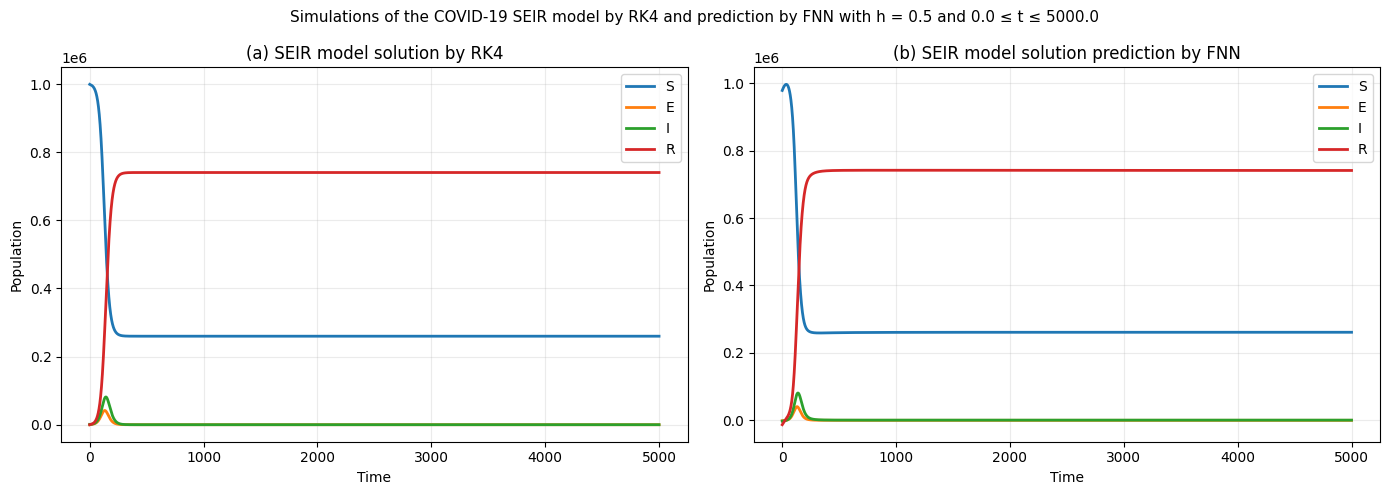

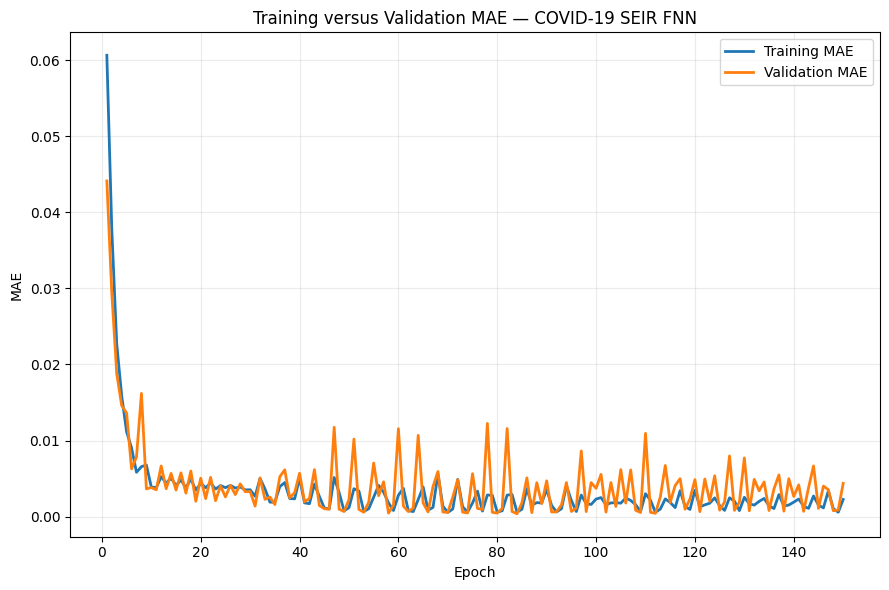

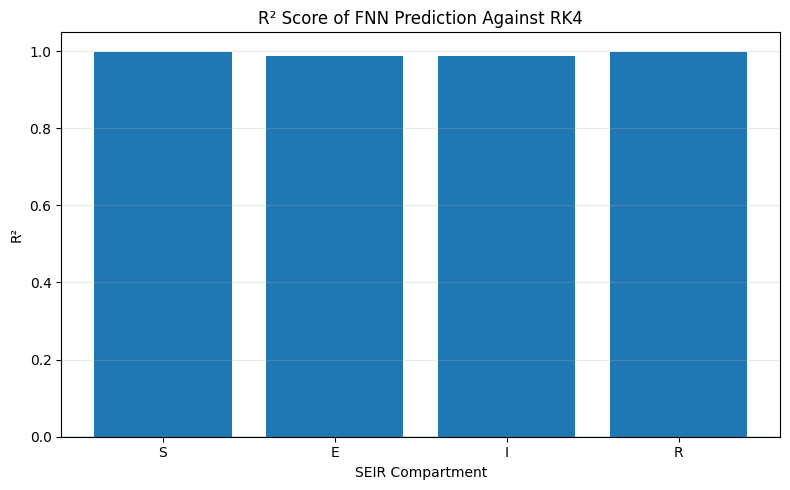

/tmp/ipykernel_16/4186797239.py:1038: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  rk4.to_excel(
/tmp/ipykernel_16/4186797239.py:1044: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  res.to_excel(
/tmp/ipykernel_16/4186797239.py:1050: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  metrics.to_excel(
/tmp/ipykernel_16/4186797239.py:1056: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  normdf.to_excel(
/tmp/ipykernel_16/4186797239.py:1062: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  Hdf.to_excel(
/tmp/ipykernel_16/4186797239.py:1068: FutureWarn


COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED
beta = 0.17150948
gamma = 0.09425424
sigma = 0.19230769
latent period = 5.20 days
beta/gamma = 1.819647

Initial state: S0=999,000, E0=0, I0=1,000, R0=0
N = 1,000,000

RK4: h=0.5, t=[0.0,5000.0], samples=10,001

Metrics (FNN vs RK4):
Compartment         MAE          MSE        RMSE       R2
          S 1940.653667 1.681622e+07 4100.758428 0.998510
          E  134.361332 2.843884e+05  533.280822 0.986281
          I  692.519063 1.022104e+06 1010.991575 0.987683
          R 1964.095479 3.729509e+07 6106.970383 0.997090

Normalized accuracy-like score:
Compartment  Normalized_MAE  Normalized_MSE  Accuracy_like_percent
          S        0.002625        0.000031              99.737476
          E        0.003099        0.000156              99.690129
          I        0.008374        0.000147              99.162568
          R        0.002609        0.000067              99.739074

Population conservation check:
RK4 maximum absolute error = 0

In [4]:
# ============================================================
# Output directory
# ============================================================

OUT = Path('/kaggle/working/COVID19_SEIR_RK4_FNN_synthetic_article_method')
OUT.mkdir(parents=True, exist_ok=True)


# ============================================================
# SEIR PARAMETERS
# ============================================================

BETA = 0.17150948
GAMMA = 0.09425424

# Sigma = rate at which exposed individuals become infectious
# Mean latent/incubation period = 1 / SIGMA
SIGMA = 1.0 / 5.2

# Initial conditions
S0 = 999000.0
E0 = 0.0
I0 = 1000.0
R0 = 0.0

# Total population
N = S0 + E0 + I0 + R0


# ============================================================
# TIME SETTINGS
# ============================================================

T0 = 0.0
T1 = 5000.0
H = 0.5


# ============================================================
# FNN SETTINGS
# ============================================================

SEED = 42

EPOCHS = 150
BATCH_SIZE = 32

# Same published-style architecture as your SIR code
HIDDEN = [16, 128, 80, 40, 16]


# ============================================================
# RANDOM SEED
# ============================================================

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ============================================================
# SEIR DIFFERENTIAL EQUATIONS
# ============================================================
#
# dS/dt = -beta*S*I/N
#
# dE/dt = beta*S*I/N - sigma*E
#
# dI/dt = sigma*E - gamma*I
#
# dR/dt = gamma*I
#
# ============================================================

def rhs(t, y):

    S, E, I, R = y

    dS = -BETA * S * I / N

    dE = BETA * S * I / N - SIGMA * E

    dI = SIGMA * E - GAMMA * I

    dR = GAMMA * I

    return np.array([dS, dE, dI, dR])


# ============================================================
# RK4 ONE STEP
# ============================================================

def rk4_step(t, y, h):

    k1 = h * rhs(t, y)

    k2 = h * rhs(
        t + h / 2,
        y + k1 / 2
    )

    k3 = h * rhs(
        t + h / 2,
        y + k2 / 2
    )

    k4 = h * rhs(
        t + h,
        y + k3
    )

    y_next = y + (
        k1 + 2*k2 + 2*k3 + k4
    ) / 6

    # Avoid negative populations
    y_next = np.maximum(y_next, 0.0)

    return y_next


# ============================================================
# GENERATE TIME ARRAY
# ============================================================

t = np.arange(
    T0,
    T1 + H / 2,
    H
)

t[-1] = T1


# ============================================================
# RK4 SYNTHETIC DATA GENERATION
# ============================================================

y = np.zeros(
    (len(t), 4)
)

# Initial conditions
y[0] = [
    S0,
    E0,
    I0,
    R0
]


# Run RK4
for j in range(len(t) - 1):

    y[j + 1] = rk4_step(
        t[j],
        y[j],
        H
    )


# ============================================================
# CREATE RK4 DATAFRAME
# ============================================================

rk4 = pd.DataFrame({
    't': t,
    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3]
})


# Total population
rk4['Total_RK4'] = rk4[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


# Population conservation error
rk4['Population_Error'] = (
    rk4['Total_RK4'] - N
)


# Save RK4 synthetic dataset
rk4.to_csv(
    OUT / 'COVID19_SEIR_RK4_synthetic_data.csv',
    index=False
)


# ============================================================
# ARTICLE-STYLE FNN
# ============================================================
#
# Input:
#       t
#
# Output:
#       S(t), E(t), I(t), R(t)
#
# ============================================================

X = t.reshape(-1, 1)

Y = y.copy()


# ============================================================
# MIN-MAX NORMALIZATION
# ============================================================

xsc = MinMaxScaler()

ysc = MinMaxScaler()


Xs = xsc.fit_transform(X)

Ys = ysc.fit_transform(Y)


# ============================================================
# 80/20 TRAIN-VALIDATION SPLIT
# ============================================================

Xtr, Xva, Ytr, Yva = train_test_split(
    Xs,
    Ys,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)


# ============================================================
# BUILD FNN
# ============================================================

model = keras.Sequential(
    [
        layers.Input((1,))
    ]
    +
    [
        layers.Dense(
            u,
            activation='tanh'
        )
        for u in HIDDEN
    ]
    +
    [
        layers.Dense(
            4,
            activation='linear'
        )
    ],
    name='COVID19_SEIR_FNN'
)


# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='mse',
    metrics=[
        keras.metrics.MeanAbsoluteError(
            name='mae'
        )
    ]
)


print(model.summary())


# ============================================================
# TRAIN FNN
# ============================================================

hist = model.fit(
    Xtr,
    Ytr,
    validation_data=(Xva, Yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


# ============================================================
# TRAINING HISTORY
# ============================================================

Hdf = pd.DataFrame(
    hist.history
)

Hdf.insert(
    0,
    'epoch',
    np.arange(
        1,
        len(Hdf) + 1
    )
)


Hdf.to_csv(
    OUT / 'FNN_training_history.csv',
    index=False
)


# ============================================================
# FULL-DOMAIN FNN PREDICTION
# ============================================================

pred_scaled = model.predict(
    Xs,
    batch_size=BATCH_SIZE,
    verbose=1
)


# Convert back to original population scale
pred = ysc.inverse_transform(
    pred_scaled
)


# ============================================================
# EXTRACT COMPARTMENTS
# ============================================================

Sfnn = pred[:, 0]
Efnn = pred[:, 1]
Ifnn = pred[:, 2]
Rfnn = pred[:, 3]


# Optional non-negative predictions
Sfnn = np.maximum(
    Sfnn,
    0
)

Efnn = np.maximum(
    Efnn,
    0
)

Ifnn = np.maximum(
    Ifnn,
    0
)

Rfnn = np.maximum(
    Rfnn,
    0
)


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame({

    't': t,

    'S_RK4': y[:, 0],
    'E_RK4': y[:, 1],
    'I_RK4': y[:, 2],
    'R_RK4': y[:, 3],

    'S_FNN': Sfnn,
    'E_FNN': Efnn,
    'I_FNN': Ifnn,
    'R_FNN': Rfnn
})


# ============================================================
# TOTAL POPULATION
# ============================================================

res['RK4_Total'] = res[
    [
        'S_RK4',
        'E_RK4',
        'I_RK4',
        'R_RK4'
    ]
].sum(axis=1)


res['FNN_Total'] = res[
    [
        'S_FNN',
        'E_FNN',
        'I_FNN',
        'R_FNN'
    ]
].sum(axis=1)


# ============================================================
# FNN TOTAL POPULATION ERROR
# ============================================================

res['FNN_Total_Error'] = (
    res['FNN_Total'] - N
)


# ============================================================
# COMPARTMENT-WISE ERRORS
# ============================================================

res['S_Error'] = (
    res['S_FNN'] - res['S_RK4']
)

res['E_Error'] = (
    res['E_FNN'] - res['E_RK4']
)

res['I_Error'] = (
    res['I_FNN'] - res['I_RK4']
)

res['R_Error'] = (
    res['R_FNN'] - res['R_RK4']
)


# Save complete results
res.to_csv(
    OUT / 'COVID19_SEIR_RK4_vs_FNN_complete.csv',
    index=False
)


# ============================================================
# METRICS
# ============================================================

rows = []


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    actual = y[:, k]

    prediction = pred[:, k]


    mse = mean_squared_error(
        actual,
        prediction
    )


    rows.append({

        'Compartment': name,

        'MAE': mean_absolute_error(
            actual,
            prediction
        ),

        'MSE': mse,

        'RMSE': np.sqrt(mse),

        'R2': r2_score(
            actual,
            prediction
        )

    })


metrics = pd.DataFrame(
    rows
)


metrics.to_csv(
    OUT / 'COVID19_SEIR_RK4_FNN_metrics.csv',
    index=False
)


# ============================================================
# NORMALIZED MAE / ACCURACY-LIKE SCORE
# ============================================================

norm = []


# Use non-negative predictions for this section
P_for_scaling = np.column_stack(
    [
        Sfnn,
        Efnn,
        Ifnn,
        Rfnn
    ]
)


Pscaled = ysc.transform(
    P_for_scaling
)


for k, name in enumerate(
    ['S', 'E', 'I', 'R']
):

    mae = mean_absolute_error(
        Ys[:, k],
        Pscaled[:, k]
    )

    mse = mean_squared_error(
        Ys[:, k],
        Pscaled[:, k]
    )


    norm.append({

        'Compartment': name,

        'Normalized_MAE': mae,

        'Normalized_MSE': mse,

        'Accuracy_like_percent':
            (1 - mae) * 100

    })


normdf = pd.DataFrame(
    norm
)


normdf.to_csv(
    OUT / 'COVID19_SEIR_FNN_normalized_accuracy.csv',
    index=False
)


# ============================================================
# FIGURE 1
# RK4 SEIR SOLUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(a) COVID-19 SEIR model solution by RK4'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_RK4_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 2
# FNN SEIR PREDICTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

plt.plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


plt.title(
    '(b) COVID-19 SEIR model solution prediction by FNN'
)

plt.xlabel('Time')

plt.ylabel('Population')

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 3
# RK4 VS FNN — SIDE BY SIDE
# ============================================================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# RK4
# ------------------------------------------------------------

ax[0].plot(
    t,
    y[:, 0],
    label='S',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 1],
    label='E',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 2],
    label='I',
    linewidth=2
)

ax[0].plot(
    t,
    y[:, 3],
    label='R',
    linewidth=2
)


ax[0].set_title(
    '(a) SEIR model solution by RK4'
)

ax[0].set_xlabel('Time')

ax[0].set_ylabel('Population')

ax[0].legend()

ax[0].grid(alpha=0.25)


# ------------------------------------------------------------
# FNN
# ------------------------------------------------------------

ax[1].plot(
    t,
    pred[:, 0],
    label='S',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 1],
    label='E',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 2],
    label='I',
    linewidth=2
)

ax[1].plot(
    t,
    pred[:, 3],
    label='R',
    linewidth=2
)


ax[1].set_title(
    '(b) SEIR model solution prediction by FNN'
)

ax[1].set_xlabel('Time')

ax[1].set_ylabel('Population')

ax[1].legend()

ax[1].grid(alpha=0.25)


fig.suptitle(
    f'Simulations of the COVID-19 SEIR model '
    f'by RK4 and prediction by FNN '
    f'with h = {H} and '
    f'{T0} ≤ t ≤ {T1}',
    fontsize=11
)


fig.tight_layout()


fig.savefig(
    OUT / 'Figure_RK4_vs_FNN_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4
# TRAINING VS VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    Hdf.epoch,
    Hdf.mae,
    label='Training MAE',
    linewidth=2
)

plt.plot(
    Hdf.epoch,
    Hdf.val_mae,
    label='Validation MAE',
    linewidth=2
)


plt.xlabel('Epoch')

plt.ylabel('MAE')

plt.title(
    'Training versus Validation MAE — COVID-19 SEIR FNN'
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_Training_Validation_MAE_SEIR.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 5
# R2 BAR CHART
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.bar(
    metrics['Compartment'],
    metrics['R2']
)


plt.axhline(
    0,
    linewidth=1
)


plt.xlabel('SEIR Compartment')

plt.ylabel('R²')

plt.title(
    'R² Score of FNN Prediction Against RK4'
)

plt.grid(
    axis='y',
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    OUT / 'Figure_R2_SEIR_FNN.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# EXCEL OUTPUT
# ============================================================

params = pd.DataFrame({

    'Parameter': [

        'Beta',
        'Gamma',
        'Sigma',
        '1/Sigma',
        'Beta/Gamma',

        'S0',
        'E0',
        'I0',
        'R0',

        'N',

        'Time_start',
        'Time_end',

        'Step_h',

        'Samples',

        'FNN_input',

        'FNN_output',

        'Normalization',

        'Train',

        'Validation',

        'Random_state',

        'Activation',

        'Optimizer',

        'Hidden_layers',

        'Epochs',

        'Batch_size'

    ],


    'Value': [

        BETA,
        GAMMA,
        SIGMA,
        1 / SIGMA,
        BETA / GAMMA,

        S0,
        E0,
        I0,
        R0,

        N,

        T0,
        T1,

        H,

        len(t),

        't',

        'S(t), E(t), I(t), R(t)',

        'Min-Max [0,1]',

        '80%',

        '20%',

        SEED,

        'tanh',

        'Adam',

        str(HIDDEN),

        EPOCHS,

        BATCH_SIZE

    ]

})


with pd.ExcelWriter(
    OUT / 'COVID19_SEIR_RK4_FNN_complete_results.xlsx',
    engine='openpyxl'
) as writer:

    rk4.to_excel(
        writer,
        'RK4_Data',
        index=False
    )

    res.to_excel(
        writer,
        'RK4_vs_FNN',
        index=False
    )

    metrics.to_excel(
        writer,
        'Metrics',
        index=False
    )

    normdf.to_excel(
        writer,
        'Normalized_Accuracy',
        index=False
    )

    Hdf.to_excel(
        writer,
        'Training_History',
        index=False
    )

    params.to_excel(
        writer,
        'Parameters',
        index=False
    )


# ============================================================
# SAVE MODEL
# ============================================================

model.save(
    OUT / 'COVID19_SEIR_FNN.keras'
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print('\n' + '=' * 80)

print('COVID-19 SEIR RK4 + FNN EXPERIMENT COMPLETED')

print('=' * 80)


print(
    f'beta = {BETA:.8f}'
)

print(
    f'gamma = {GAMMA:.8f}'
)

print(
    f'sigma = {SIGMA:.8f}'
)

print(
    f'latent period = {1/SIGMA:.2f} days'
)

print(
    f'beta/gamma = {BETA/GAMMA:.6f}'
)


print(
    f'\nInitial state: '
    f'S0={S0:,.0f}, '
    f'E0={E0:,.0f}, '
    f'I0={I0:,.0f}, '
    f'R0={R0:,.0f}'
)


print(
    f'N = {N:,.0f}'
)


print(
    f'\nRK4: h={H}, '
    f't=[{T0},{T1}], '
    f'samples={len(t):,}'
)


print(
    '\nMetrics (FNN vs RK4):'
)

print(
    metrics.to_string(
        index=False
    )
)


print(
    '\nNormalized accuracy-like score:'
)

print(
    normdf.to_string(
        index=False
    )
)


print(
    '\nPopulation conservation check:'
)

print(
    f'RK4 maximum absolute error = '
    f'{np.max(np.abs(rk4["Population_Error"])):.10f}'
)


print(
    '\nOutputs saved to:'
)

print(
    OUT
)

print('=' * 80)

***
### References
[^1]: Pant B, Levine ME, Nande A, Garcia RG, Dewey G, Link NB, Santillana M. Resolving parameter uncertainty in SIR models through population-level serological surveillance: A synthetic study. *Infect Dis Model*. 2026;11(4):1491-1503. doi:10.1016/j.idm.2026.05.004
<br>[^2] Tuncer N, Le TT. Structural and practical identifiability analysis of outbreak models. Math Biosci. 2018 May;299:1-18. doi: 10.1016/j.mbs.2018.02.004. Epub 2018 Mar 29. PMID: 29477671.